## 2.1 黎曼零点分布统计

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath  # Python 的高精度数学库，内置了黎曼 ζ 函数零点数据

# =====================================================================
# 步骤 1: 抓取大自然的真实数据 (获取前 2000 个黎曼零点)
# =====================================================================
print("正在向数学真理发起请求，计算前 2000 个黎曼零点...")
# mpmath.zetazero(i) 会算出第 i 个零点 (例如 0.5 + 14.1347i)
# 黎曼猜想认为它们的实部都是 0.5，所以我们只提取它的虚部 (高度)
zeros = np.array([float(mpmath.zetazero(i).imag) for i in range(1, 2001)])

# =====================================================================
# 步骤 2: 计算零点之间的原始间距 (Gap)
# =====================================================================
# 用后一个零点减去前一个零点，看看它们离得有多远
spacings = np.diff(zeros)

# =====================================================================
# 步骤 3: 物理学上的“清洗” (谱展开 Unfolding)
# =====================================================================
# 核心常识：黎曼零点越往高处走，分布得越密集。
# 为了公平对比，我们需要用它的真实密度公式 rho(t) 把这个“越走越密”的趋势抹平。
# 数学家算出的黎曼零点密度公式是：rho(t) = (1 / 2π) * ln(t / 2π)
rho = np.log(zeros[:-1] / (2 * np.pi)) / (2 * np.pi)
s_unfolded = spacings * rho

正在向数学真理发起请求，计算前 2000 个黎曼零点...


### 核心代码精讲：给数学常数“做手术”（谱展开）

我们重点来看这两行看起来有点像魔法的代码：

```python
rho = np.log(zeros[:-1] / (2 * np.pi)) / (2 * np.pi)
s_unfolded = spacings * rho

```

要想看懂它们，我们得分别从 **“计算机（Numpy）的脾气”** 和 **“黎曼猜想的数学本质”** 两个维度来破解。

#### 1. `zeros[:-1]` 到底是什么鬼？（Numpy 的对齐强迫症）

首先，`zeros` 是我们刚刚抓取下来的一个长长的数组，里面装了 2000 个黎曼零点的高度。
而 `spacings` 是我们用 `np.diff(zeros)` 算出来的**间距**。

> **思考一个植树问题**：
> 如果你有 2000 棵树（零点），它们中间有多少个间距？
> 答案是：1999 个。

这就是计算机的强迫症了。`spacings` 这个数组只有 1999 个元素，但 `zeros` 有 2000 个元素。如果我们要在下一步把它们乘起来，Python 就会报错：“对不起，两个数组长度不一样，我乘不了！”

* **`:-1` 的魔法**：在 Python 的切片（Slicing）语法中，`:` 代表“取全部”，而 `-1` 代表“倒数第一个”。合在一起，`zeros[:-1]` 的意思就是：**“从头开始取，但把最后一个零点给我砍掉！”**
* **结果**：砍掉最后一个零点后，`zeros[:-1]` 的长度也变成了 1999。这样，每一个“间距”都能和一个“零点的位置”完美地、一对一地对应上了！

#### 2. `rho` 是怎么来的？（黎曼-冯·曼戈尔特密度公式）

在数学上，黎曼零点有一个极其“恶心”的特性：**越往数轴的高处走，零点分布得越密集。**

* 这就好比一条越来越拥堵的高速公路。如果在起点，两辆车相距 10 米，我们觉得很近；但在极度拥堵的终点，相距 10 米可能算是很远了。
* 为了公平地研究它们的“排斥力”，我们必须消除这种宏观上的拥堵趋势。数学上，这叫**谱展开（Unfolding）**。

黎曼本人和后来的数学家冯·曼戈尔特（von Mangoldt）推导出了一个公式：在高度为  的地方，零点的**密度（Density，用符号  表示）**大约是：


你看 `rho = np.log(...) / (2 * np.pi)`，这简直就是**把上面这个数学公式，一个符号都不差地照抄成了代码！** Numpy 会瞬间计算出这 1999 个位置上，各自的局部拥堵程度。

#### 3. `spacings * rho` 是在干什么？（拉平宇宙的刻度尺）

这是最神奇的一步！

* `spacings`（原始间距）
* `rho`（局部密度）

既然高处的密度  很大，原本的间距 `spacings` 自然就很小。
当我们执行 `spacings * rho` 时，Numpy 会把它们**逐个元素相乘**。这就相当于：**把那些因为拥堵而挤在一起的间距，按照它所在位置的密度，强行“放大”拉伸开来。**

**最终效果**：
经过 `s_unfolded` 这一步，我们成功地把一把刻度不均匀、越来越密的尺子，强行“掰直”成了一把刻度均匀的尺子。只有在这把绝对公平的尺子下，我们才能看清零点之间到底存不存在真正的“量子排斥力”！


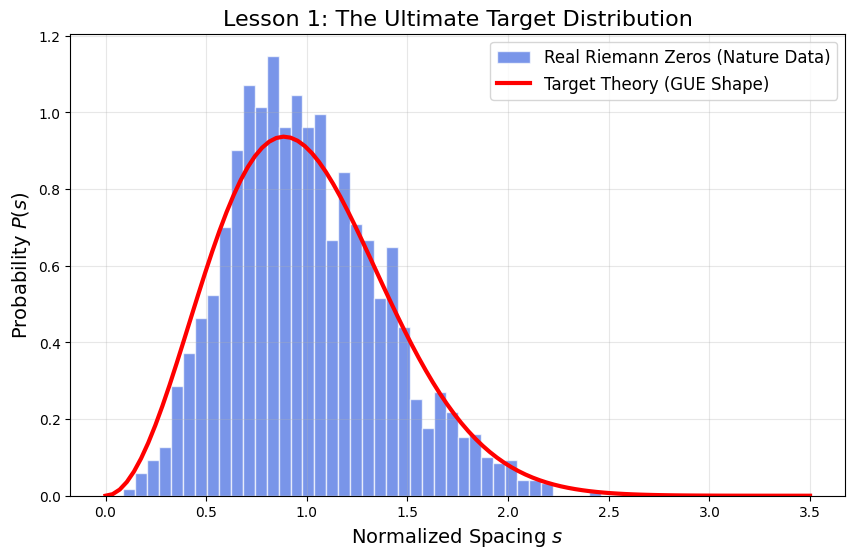

In [4]:
# =====================================================================
# 步骤 4: 均值归一化 (让平均间距严格等于 1)
# =====================================================================
# 把清洗后的间距除以它们的平均值。
# 这一步是为了让“微观量子系统”、“宏观无人机”和“素数”能在同一个尺度下对比。
s_final = s_unfolded / np.mean(s_unfolded)

# =====================================================================
# 步骤 5: 画出我们的“目标指纹图”
# =====================================================================
plt.figure(figsize=(10, 6))

# 1. 画出真实黎曼零点间距的直方图 (我们的目标数据)
plt.hist(s_final, bins=40, density=True, alpha=0.7, color='royalblue', 
         edgecolor='white', label='Real Riemann Zeros (Nature Data)')

# 2. 画出理论的“目标轮廓线” (Wigner Surmise / GUE)
# 为了让 AI 有个明确的数学拟合目标，我们把理论公式画上去
x = np.linspace(0, 3.5, 100)
gue_theory = (32 / np.pi**2) * (x**2) * np.exp(-(4 / np.pi) * x**2)
plt.plot(x, gue_theory, 'r-', lw=3, label='Target Theory (GUE Shape)')

# 图表装饰
plt.title("Lesson 1: The Ultimate Target Distribution", fontsize=16)
plt.xlabel("Normalized Spacing $s$", fontsize=14)
plt.ylabel("Probability $P(s)$", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()